<a href="https://colab.research.google.com/github/wagborba/calculadora-dfc/blob/main/01_risco_inadimplencia_QNN_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Risco de Inadimplência — Classificação com QNN

Este notebook foi feito para a atividade prática de QNN.

O aluno deve mudar apenas as listas de parâmetros, rodar os testes, escolher uma configuração final e copiar os gráficos para o relatório.

**O código gera:**

1. gráfico da loss ao final de cada configuração;
2. tabela simples com os resultados;
3. gráfico final de loss;
4. gráfico final de treino vs teste;
5. gráfico final variando camadas e qubits, com nome, CPF, data e horário fora da área principal do gráfico.


In [ ]:
# PREENCHA ANTES DE RODAR O NOTEBOOK
NOME = "Cesar"
CPF = "283812739812"

if NOME.strip() == "" or CPF.strip() == "":
    print("ATENÇÃO: preencha NOME e CPF antes de continuar.")
else:
    print(f"Aluno(a): {NOME} | CPF: {CPF}")


Aluno(a): Cesar | CPF: 283812739812


In [ ]:
# Imports básicos
# Se estiver no Google Colab e não tiver PennyLane instalado, descomente a linha abaixo.
!pip install -q pennylane

import time
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import pennylane as qml

# IMPORTANTE:
# Usamos float64 em tudo para evitar erro do tipo:
# RuntimeError: Found dtype Float but expected Double
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

np.random.seed(42)
torch.manual_seed(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 41.3 MB/s eta 0:00:00


In [ ]:
# ======================================================
# PARÂMETROS QUE OS ALUNOS PODEM MUDAR
# ======================================================

# Comece com listas pequenas para rodar rápido.
# Depois, teste mais valores se quiser.
LEARNING_RATES = [0.1]
EPOCHS_LIST = [50]
LAYERS_LIST = [1, 2]
QUBITS_LIST = [2]

# Dados simulados da atividade
N_AMOSTRAS = 100
TEST_RATIO = 0.25
SEED_DADOS = 42

# Para o gráfico 3 final, o código compara camadas e qubits
# mantendo o learning rate e o número de épocas escolhidos no final.


In [ ]:
# ======================================================
# FUNÇÕES DE NORMALIZAÇÃO
# ======================================================
# Aqui o min-max fica definido corretamente.
# Não existe chamada para uma função "minmax" solta/indefinida.

def minmax_fit(X):
    minimo = X.min(axis=0, keepdims=True)
    maximo = X.max(axis=0, keepdims=True)
    return minimo, maximo


def minmax_transform(X, minimo, maximo):
    return (X - minimo) / (maximo - minimo + 1e-8)


def minmax_fit_transform(X):
    minimo, maximo = minmax_fit(X)
    return minmax_transform(X, minimo, maximo), minimo, maximo


def separar_treino_teste(X, y, test_ratio=0.25, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)

    corte = int(len(X) * (1 - test_ratio))
    idx_treino = idx[:corte]
    idx_teste = idx[corte:]

    return X[idx_treino], y[idx_treino], X[idx_teste], y[idx_teste]


## 1. Preparação dos dados

In [ ]:
# ======================================================
# DADOS SIMULADOS — RISCO DE INADIMPLÊNCIA
# ======================================================
PROBLEMA = "Risco de inadimplência"
FEATURES = [
    "divida_renda",
    "uso_limite",
    "atrasos_anteriores",
    "renda",
    "reserva_financeira",
]


def preparar_dados(n=N_AMOSTRAS, test_ratio=TEST_RATIO, seed=SEED_DADOS):
    rng = np.random.default_rng(seed)

    divida_renda = rng.uniform(0, 1, n)
    uso_limite = rng.uniform(0, 1, n)
    atrasos_anteriores = rng.uniform(0, 1, n)
    renda = rng.uniform(1000, 9000, n)
    reserva_financeira = rng.uniform(0, 1, n)

    X = np.stack([
        divida_renda,
        uso_limite,
        atrasos_anteriores,
        renda,
        reserva_financeira,
    ], axis=1)

    score = (
        1.5 * divida_renda
        + 1.2 * uso_limite
        + 1.1 * atrasos_anteriores
        - 0.00008 * renda
        - 0.8 * reserva_financeira
        + rng.normal(0, 0.15, n)
    )
    y = (score > np.quantile(score, 0.65)).astype(np.float64)

    Xtr_np, ytr_np, Xte_np, yte_np = separar_treino_teste(X, y, test_ratio, seed)

    Xtr_np, X_min, X_max = minmax_fit_transform(Xtr_np)
    Xte_np = minmax_transform(Xte_np, X_min, X_max)

    return (
        torch.tensor(Xtr_np, dtype=DTYPE),
        torch.tensor(ytr_np, dtype=DTYPE),
        torch.tensor(Xte_np, dtype=DTYPE),
        torch.tensor(yte_np, dtype=DTYPE),
    )


Xtr, ytr, Xte, yte = preparar_dados()

print("Problema:", PROBLEMA)
print("Features:", FEATURES)
print("Formato treino:", Xtr.shape, ytr.shape)
print("Formato teste:", Xte.shape, yte.shape)
print("Proporção classe 1 no treino:", float(ytr.mean()))


Problema: Risco de inadimplência
Features: ['divida_renda', 'uso_limite', 'atrasos_anteriores', 'renda', 'reserva_financeira']
Formato treino: torch.Size([75, 5]) torch.Size([75])
Formato teste: torch.Size([25, 5]) torch.Size([25])
Proporção classe 1 no treino: 0.36


## 2. Modelo QNN

In [ ]:
# ======================================================
# MODELO QNN SIMPLES
# ======================================================

def ajustar_features_para_qubits(X, n_qubits):
    """Seleciona as primeiras features ou completa com zeros para bater com n_qubits."""
    X = X.to(dtype=DTYPE)

    if X.shape[1] >= n_qubits:
        return X[:, :n_qubits]

    faltam = n_qubits - X.shape[1]
    zeros = torch.zeros((X.shape[0], faltam), dtype=DTYPE)
    return torch.cat([X, zeros], dim=1)


class QNN(torch.nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.dev = qml.device("default.qubit", wires=n_qubits)

        # Parâmetros treináveis do circuito.
        # torch.nn.Parameter garante que o tensor é leaf e treinável pelo otimizador.
        self.weights = torch.nn.Parameter(
            0.1 * torch.randn(n_layers, n_qubits, 3, dtype=DTYPE)
        )
        self.bias = torch.nn.Parameter(torch.zeros(1, dtype=DTYPE))

        @qml.qnode(self.dev, interface="torch", diff_method="backprop")
        def circuito(x, weights):
            # Feature map: dados clássicos -> rotações quânticas
            qml.AngleEmbedding(np.pi * x, wires=range(n_qubits), rotation="Y")

            # Ansatz variacional
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

            # Readout: valor esperado de Z no primeiro qubit
            return qml.expval(qml.PauliZ(0))

        self.circuito = circuito

    def forward(self, X):
        saidas = []
        for x in X:
            saidas.append(self.circuito(x, self.weights))
        saidas = torch.stack(saidas).reshape(-1)
        return saidas + self.bias[0]


## 3. Funções de treino

In [ ]:
# ======================================================
# TREINAMENTO E MÉTRICAS — CLASSIFICAÇÃO
# ======================================================

def metricas_classificacao(logits, y):
    y = y.to(dtype=DTYPE)
    prob = torch.sigmoid(logits)
    pred = (prob >= 0.5).to(dtype=DTYPE)

    acc = (pred == y).to(dtype=DTYPE).mean().item()

    tp = ((pred == 1) & (y == 1)).sum().item()
    fp = ((pred == 1) & (y == 0)).sum().item()
    fn = ((pred == 0) & (y == 1)).sum().item()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return acc, f1


def treinar_qnn(lr, epochs, n_layers, n_qubits):
    Xtr_q = ajustar_features_para_qubits(Xtr, n_qubits)
    Xte_q = ajustar_features_para_qubits(Xte, n_qubits)

    model = QNN(n_qubits=n_qubits, n_layers=n_layers)
    loss_fn = torch.nn.BCEWithLogitsLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    inicio = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        logits = model(Xtr_q)
        loss = loss_fn(logits, ytr)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_history.append(float(loss.item()))

    model.eval()
    with torch.no_grad():
        logits_tr = model(Xtr_q)
        logits_te = model(Xte_q)

        acc_tr, f1_tr = metricas_classificacao(logits_tr, ytr)
        acc_te, f1_te = metricas_classificacao(logits_te, yte)

    return {
        "lr": lr,
        "epochs": epochs,
        "layers": n_layers,
        "qubits": n_qubits,
        "loss_history": loss_history,
        "train_metric": f1_tr,
        "test_metric": f1_te,
        "train_acc": acc_tr,
        "test_acc": acc_te,
        "metric_name": "F1-score",
        "tempo_seg": time.perf_counter() - inicio,
        "model": model,
    }


def plotar_loss_configuracao(r):
    plt.figure(figsize=(6, 3.5))
    plt.plot(r["loss_history"])
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(
        f"Loss finalizada | lr={r['lr']} | épocas={r['epochs']} | "
        f"camadas={r['layers']} | qubits={r['qubits']}"
    )
    plt.grid(True, alpha=0.3)
    plt.show()


## 4. Rodar várias configurações

Rodando: lr=0.1, epochs=50, camadas=1, qubits=2


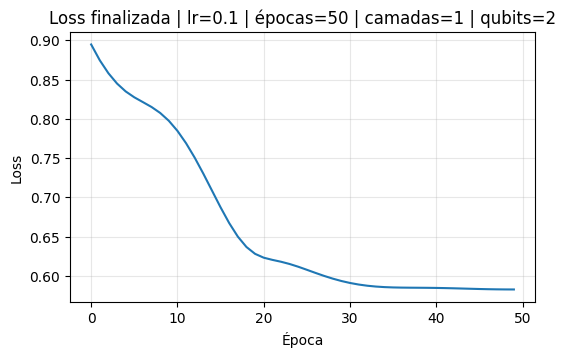

Rodando: lr=0.1, epochs=50, camadas=2, qubits=2


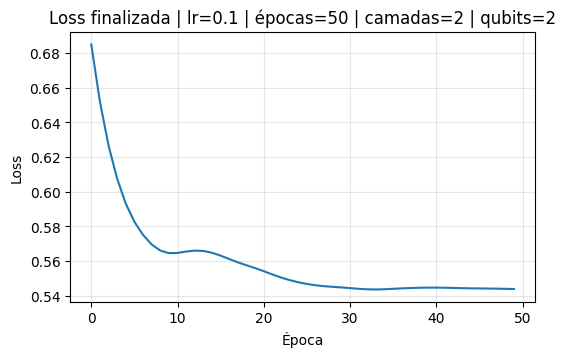


Tabela de resultados:
 id  lr  epochs  camadas  qubits  F1 treino  F1 teste  Accuracy treino  Accuracy teste  loss final  tempo (s)
  1 0.1      50        2       2   0.585366  0.500000         0.773333            0.76    0.543908  38.092198
  0 0.1      50        1       2   0.538462  0.285714         0.680000            0.60    0.582700  29.453213


In [ ]:
# ======================================================
# RODAR AS CONFIGURAÇÕES
# ======================================================
# Quando cada configuração termina, o código plota a loss daquela configuração.

resultados = []

for lr in LEARNING_RATES:
    for epochs in EPOCHS_LIST:
        for layers in LAYERS_LIST:
            for qubits in QUBITS_LIST:
                print(f"Rodando: lr={lr}, epochs={epochs}, camadas={layers}, qubits={qubits}")
                r = treinar_qnn(lr=lr, epochs=epochs, n_layers=layers, n_qubits=qubits)
                resultados.append(r)
                plotar_loss_configuracao(r)


def montar_tabela_resultados(resultados):
    linhas = []
    for i, r in enumerate(resultados):
        linhas.append({
            "id": i,
            "lr": r["lr"],
            "epochs": r["epochs"],
            "camadas": r["layers"],
            "qubits": r["qubits"],
            "F1 treino": r["train_metric"],
            "F1 teste": r["test_metric"],
            "Accuracy treino": r["train_acc"],
            "Accuracy teste": r["test_acc"],
            "loss final": r["loss_history"][-1],
            "tempo (s)": r["tempo_seg"],
        })
    return pd.DataFrame(linhas).sort_values("F1 teste", ascending=False)

resultados_df = montar_tabela_resultados(resultados)
print("\nTabela de resultados:")
print(resultados_df.to_string(index=False))


## 5. Escolher uma configuração final

Configuração escolhida não estava na lista rodada. Treinando agora...


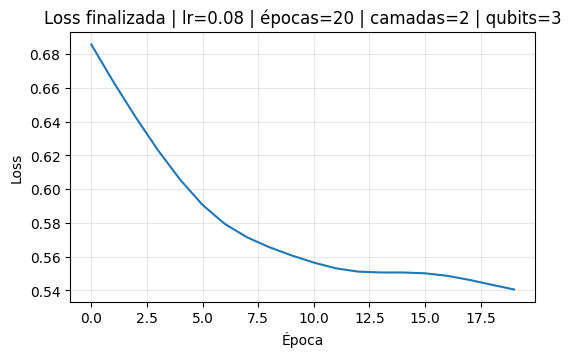

Configuração escolhida:
lr = 0.08
épocas = 20
camadas = 2
qubits = 3
F1 treino = 0.5405
F1 teste = 0.7692
Accuracy treino = 0.7733
Accuracy teste = 0.8800
Tempo = 35.45 s


In [ ]:
# ======================================================
# ESCOLHA FINAL DO ALUNO
# ======================================================
# Escolha uma configuração para usar nos gráficos finais.
# Ela pode ser uma configuração já rodada acima.
# Se não tiver sido rodada, o código treina essa configuração agora.

SELECTED_LR = 0.1
SELECTED_EPOCHS = 50
SELECTED_LAYERS = 2
SELECTED_QUBITS = 3


def obter_resultado_escolhido():
    global resultados, resultados_df

    for r in resultados:
        if (
            r["lr"] == SELECTED_LR
            and r["epochs"] == SELECTED_EPOCHS
            and r["layers"] == SELECTED_LAYERS
            and r["qubits"] == SELECTED_QUBITS
        ):
            return r

    print("Configuração escolhida não estava na lista rodada. Treinando agora...")
    r = treinar_qnn(
        lr=SELECTED_LR,
        epochs=SELECTED_EPOCHS,
        n_layers=SELECTED_LAYERS,
        n_qubits=SELECTED_QUBITS,
    )
    resultados.append(r)
    plotar_loss_configuracao(r)
    resultados_df = montar_tabela_resultados(resultados)
    return r


escolhido = obter_resultado_escolhido()

print("Configuração escolhida:")
print(f"lr = {escolhido['lr']}")
print(f"épocas = {escolhido['epochs']}")
print(f"camadas = {escolhido['layers']}")
print(f"qubits = {escolhido['qubits']}")
print(f"F1 treino = {escolhido['train_metric']:.4f}")
print(f"F1 teste = {escolhido['test_metric']:.4f}")
print(f"Accuracy treino = {escolhido['train_acc']:.4f}")
print(f"Accuracy teste = {escolhido['test_acc']:.4f}")
print(f"Tempo = {escolhido['tempo_seg']:.2f} s")


## 6. Gráficos finais e tabela-resumo

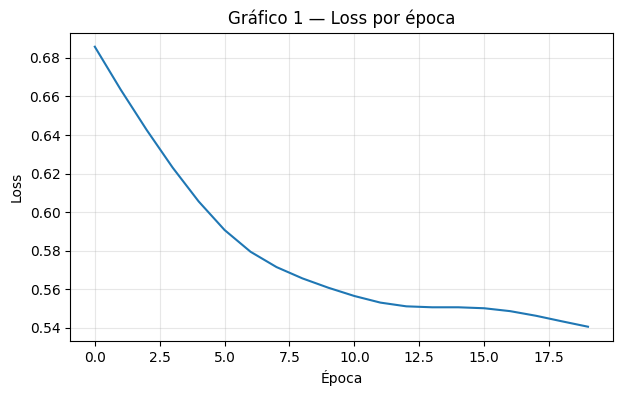

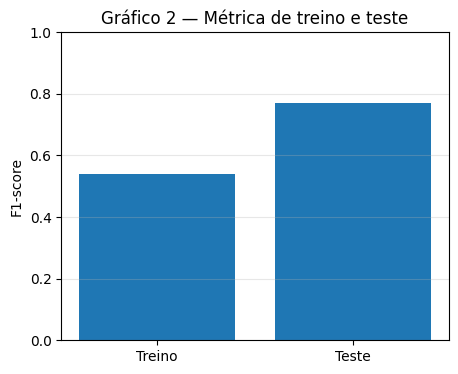

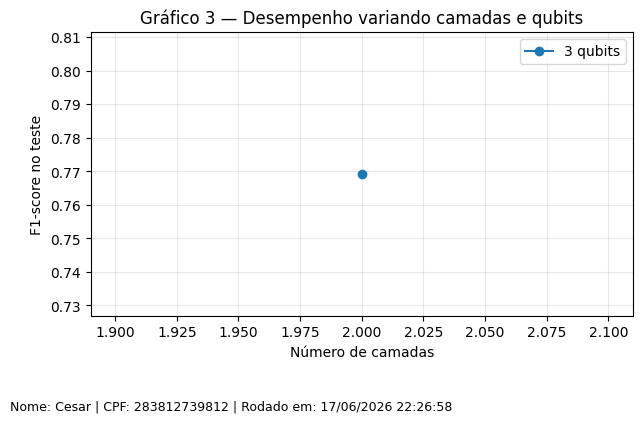


Tabela-resumo:
                           Item                         Resultado
             Problema escolhido            Risco de inadimplência
                           Tipo                     Classificação
                  Métrica usada               F1-score e Accuracy
        Learning rate escolhido                              0.08
     Número de épocas escolhido                                20
    Número de camadas escolhido                                 2
     Número de qubits escolhido                                 3
            Resultado no treino             F1=0.5405; Acc=0.7733
             Resultado no teste             F1=0.7692; Acc=0.8800
              Tempo de execução                           35.45 s
Houve overfitting/underfitting? Preencher olhando treino vs teste
     O treinamento foi estável? Preencher olhando a curva de loss
  Principal limitação observada   Preencher com base nos gráficos


In [ ]:
# ======================================================
# GRÁFICOS FINAIS PARA O RELATÓRIO
# ======================================================

# Gráfico 1 — Loss por época
plt.figure(figsize=(7, 4))
plt.plot(escolhido["loss_history"])
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Gráfico 1 — Loss por época")
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico 2 — Métrica de treino e teste
plt.figure(figsize=(5, 4))
plt.bar(["Treino", "Teste"], [escolhido["train_metric"], escolhido["test_metric"]])
plt.ylabel("F1-score")
plt.title("Gráfico 2 — Métrica de treino e teste")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Gráfico 3 — Resultado variando camadas e qubits
# Mantém o learning rate e o número de épocas escolhidos.
df_plot = resultados_df[
    (resultados_df["lr"] == SELECTED_LR) &
    (resultados_df["epochs"] == SELECTED_EPOCHS)
]

if len(df_plot) == 0:
    df_plot = resultados_df.copy()

fig, ax = plt.subplots(figsize=(7, 4.5))
for q in sorted(df_plot["qubits"].unique()):
    dfq = df_plot[df_plot["qubits"] == q].sort_values("camadas")
    ax.plot(dfq["camadas"], dfq["F1 teste"], marker="o", label=f"{q} qubits")

ax.set_xlabel("Número de camadas")
ax.set_ylabel("F1-score no teste")
ax.set_title("Gráfico 3 — Desempenho variando camadas e qubits")
ax.grid(True, alpha=0.3)
ax.legend()

agora = datetime.now().strftime("%d/%m/%Y %H:%M:%S")
fig.subplots_adjust(bottom=0.25)
fig.text(0.01, 0.04, f"Nome: {NOME} | CPF: {CPF} | Rodado em: {agora}", fontsize=9)
plt.show()

# Tabela-resumo para ajudar a preencher o relatório
resumo = pd.DataFrame({
    "Item": [
        "Problema escolhido",
        "Tipo",
        "Métrica usada",
        "Learning rate escolhido",
        "Número de épocas escolhido",
        "Número de camadas escolhido",
        "Número de qubits escolhido",
        "Resultado no treino",
        "Resultado no teste",
        "Tempo de execução",
        "Houve overfitting/underfitting?",
        "O treinamento foi estável?",
        "Principal limitação observada",
    ],
    "Resultado": [
        PROBLEMA,
        "Classificação",
        "F1-score e Accuracy",
        escolhido["lr"],
        escolhido["epochs"],
        escolhido["layers"],
        escolhido["qubits"],
        f"F1={escolhido['train_metric']:.4f}; Acc={escolhido['train_acc']:.4f}",
        f"F1={escolhido['test_metric']:.4f}; Acc={escolhido['test_acc']:.4f}",
        f"{escolhido['tempo_seg']:.2f} s",
        "Preencher olhando treino vs teste",
        "Preencher olhando a curva de loss",
        "Preencher com base nos gráficos",
    ]
})

print("\nTabela-resumo:")
print(resumo.to_string(index=False))
